# Predicción de Retrasos en Vuelos Domésticos en EE.UU.
## Trabajo de Fin de Máster — Universidad Complutense de Madrid
### Máster en Data Science, Big Data e Inteligencia Artificial

---

**Autor:** Ricardo Andrés Mendez Nieto

**Tutores:** Carlos Ortega y Santiago Mota

**Curso académico:** 2025-2026

**Dataset:** Flight Delay Dataset 2024 — Kaggle
*(+7 millones de registros reales de vuelos domésticos en EE.UU.)*

---

### Descripción del proyecto

Este proyecto analiza y modela predictivamente los retrasos en vuelos domésticos
en Estados Unidos durante 2024. A través de técnicas de Machine Learning,
se construye un modelo capaz de predecir si un vuelo sufrirá un retraso
superior a 15 minutos, identificando los factores más influyentes y
aportando valor accionable al sector del transporte aéreo.

### Estructura del notebook

1. Configuración del entorno
2. Carga y exploración del dataset
3. Análisis Exploratorio de Datos (EDA)
4. Preprocesamiento y transformación de variables
5. Modelización y comparativa de algoritmos
6. Evaluación y métricas de rendimiento
7. Interpretabilidad con SHAP values
8. Prototipo productivizable
9. Conclusiones

## 1. Configuración del entorno
Instalación de librerías necesarias y conexión con Kaggle para la descarga del dataset.

In [1]:
import os
os.environ['KAGGLE_TOKEN'] = 'KGAT_c3d7d7f1b81ce206785cf4df90fcb566'

!pip install kaggle -q

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write(os.environ['KAGGLE_TOKEN'])

os.chmod('/root/.kaggle/access_token', 0o600)

print("Kaggle configurado correctamente")

Kaggle configurado correctamente


In [2]:
!kaggle datasets download -d hrishitpatil/flight-data-2024 --unzip -p /content/data/

import os
archivos = os.listdir('/content/data/')
print("Archivos descargados:")
for a in archivos:
    print(f"  - {a}")

Dataset URL: https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024
License(s): CC0-1.0
100% 270M/270M [00:13<00:00, 20.7MB/s]

Archivos descargados:
  - flight_data_2024.csv
  - flight_data_2024_data_dictionary.csv
  - flight_data_2024_sample.csv


## 2. Carga y exploración inicial del dataset

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset
df = pd.read_csv('/content/data/flight_data_2024.csv')

# Exploración inicial
print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{list(df.columns)}")
print(f"\nPrimeras 5 filas:")
df.head()

Dimensiones del dataset: 7,079,081 filas x 35 columnas

Columnas disponibles:
['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

Primeras 5 filas:


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


### 2.1 Información general del dataset

In [4]:
# Tipos de datos y valores nulos
print("Información general del dataset:")
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print("\nTipos de datos y valores nulos por columna:")
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores nulos': df.isnull().sum(),
    'Porcentaje nulos (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)

print("\nEstadísticas descriptivas de las columnas clave:")
columnas_clave = ['dep_delay', 'arr_delay', 'distance', 'air_time',
                  'carrier_delay', 'weather_delay', 'nas_delay',
                  'security_delay', 'late_aircraft_delay']
df[columnas_clave].describe().round(2)

Información general del dataset:

Memoria utilizada: 4676.9 MB

Tipos de datos y valores nulos por columna:
                        Tipo  Valores nulos  Porcentaje nulos (%)
year                   int64              0                  0.00
month                  int64              0                  0.00
day_of_month           int64              0                  0.00
day_of_week            int64              0                  0.00
fl_date               object              0                  0.00
op_unique_carrier     object              0                  0.00
op_carrier_fl_num    float64              1                  0.00
origin                object              0                  0.00
origin_city_name      object              0                  0.00
origin_state_nm       object              0                  0.00
dest                  object              0                  0.00
dest_city_name        object              0                  0.00
dest_state_nm         object      

,dep_delay,arr_delay,distance,air_time,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,6986111.00,6965267.00,7079081.00,6965267.00,7079081.00,7079081.00,7079081.00,7079081.00,7079081.00
mean,12.68,7.10,833.91,115.00,5.06,0.88,2.77,0.03,5.93
std,56.06,57.99,596.25,70.37,35.73,15.43,15.46,1.42,31.06
min,-96.00,-126.00,11.00,5.00,0.00,0.00,0.00,0.00,0.00
25%,-6.00,-15.00,399.00,63.00,0.00,0.00,0.00,0.00,0.00
50%,-2.00,-6.00,680.00,98.00,0.00,0.00,0.00,0.00,0.00
75%,9.00,9.00,1069.00,145.00,0.00,0.00,0.00,0.00,0.00
max,3777.00,3803.00,5095.00,723.00,3689.00,1804.00,2700.00,1164.00,2690.00


### 2.2 Creación de la variable objetivo

In [5]:
# Eliminamos vuelos cancelados (no tienen arr_delay por definición)
df = df[df['cancelled'] == 0].copy()

# Eliminamos filas sin arr_delay (vuelos desviados u otros casos excepcionales)
df = df[df['arr_delay'].notna()].copy()

# Variable objetivo: 1 si el vuelo llegó con más de 15 minutos de retraso, 0 si no
df['retraso'] = (df['arr_delay'] > 15).astype(int)

# Distribución de la variable objetivo
total = len(df)
retrasados = df['retraso'].sum()
puntuales = total - retrasados

print("Distribución de la variable objetivo:")
print(f"  Vuelos puntuales (retraso <= 15 min): {puntuales:,} ({puntuales/total*100:.1f}%)")
print(f"  Vuelos retrasados (retraso > 15 min): {retrasados:,} ({retrasados/total*100:.1f}%)")
print(f"\nTotal de vuelos válidos para el análisis: {total:,}")

Distribución de la variable objetivo:
  Vuelos puntuales (retraso <= 15 min): 5,561,879 (79.9%)
  Vuelos retrasados (retraso > 15 min): 1,403,388 (20.1%)

Total de vuelos válidos para el análisis: 6,965,267


## 3. Análisis Exploratorio de Datos (EDA)
### 3.1 Distribución de retrasos por mes

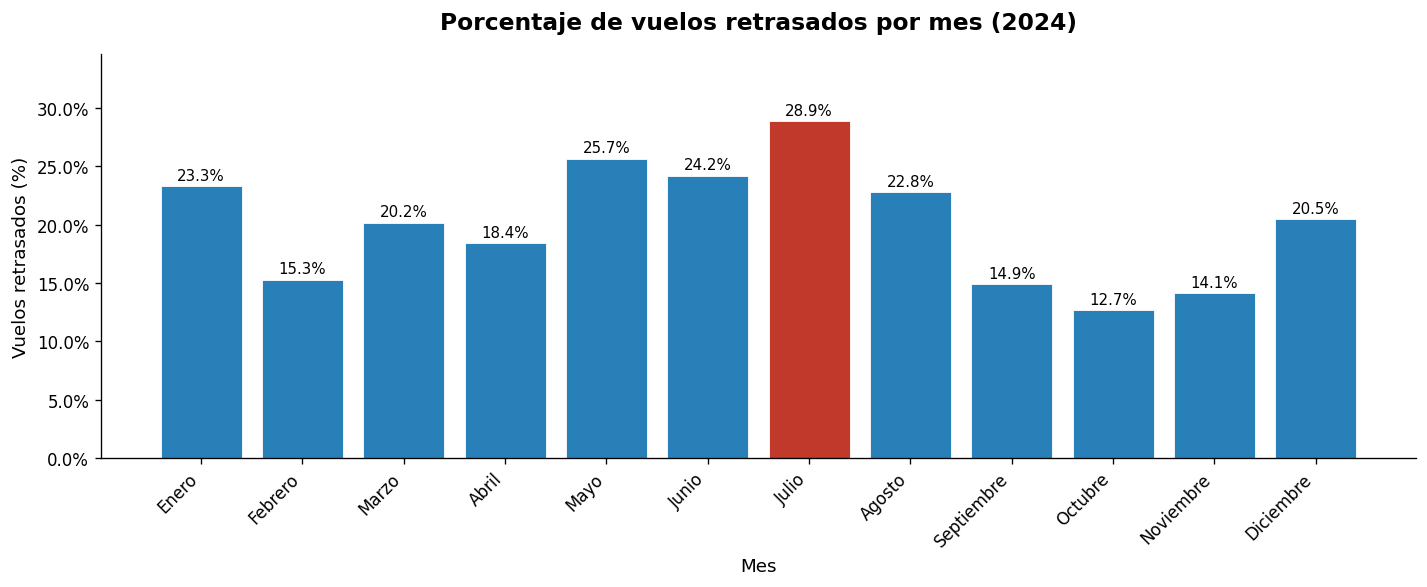

Grafica guardada correctamente.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual general
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

nombres_meses = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril',
                 5:'Mayo', 6:'Junio', 7:'Julio', 8:'Agosto',
                 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

retrasos_mes = df.groupby('month')['retraso'].mean() * 100
retrasos_mes.index = retrasos_mes.index.map(nombres_meses)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(retrasos_mes.index, retrasos_mes.values,
              color=['#c0392b' if v == retrasos_mes.max()
                     else '#2980b9' for v in retrasos_mes.values],
              edgecolor='white', linewidth=0.5)

ax.set_title('Porcentaje de vuelos retrasados por mes (2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Vuelos retrasados (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_ylim(0, retrasos_mes.max() * 1.2)

for bar, val in zip(bars, retrasos_mes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('retrasos_por_mes.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

### 3.2 Retrasos por aerolínea

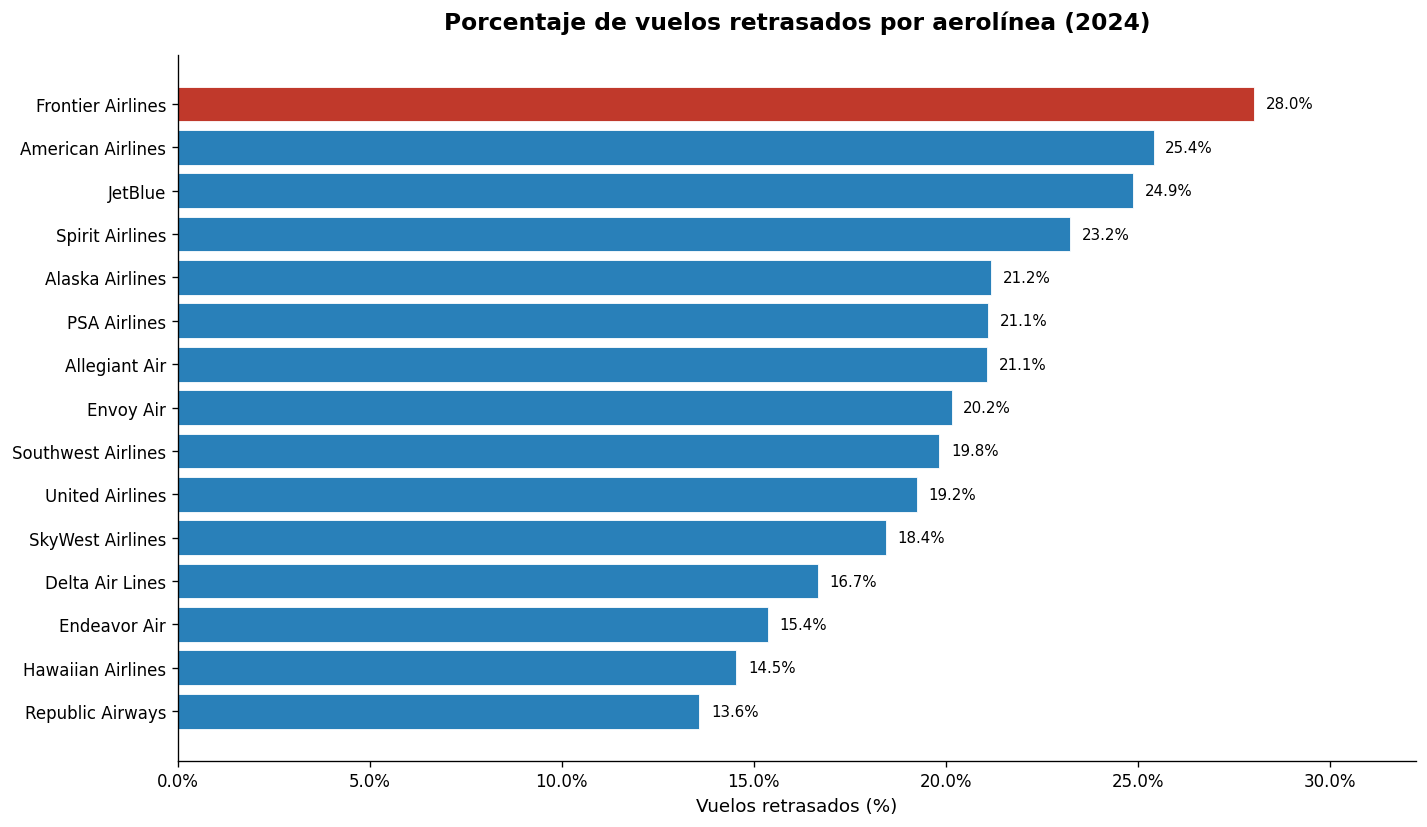

Grafica guardada correctamente.


In [7]:
aerolineas_nombres = {
    'AA': 'American Airlines', 'DL': 'Delta Air Lines',
    'UA': 'United Airlines', 'WN': 'Southwest Airlines',
    'B6': 'JetBlue', 'AS': 'Alaska Airlines',
    'NK': 'Spirit Airlines', 'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air', 'HA': 'Hawaiian Airlines',
    'SY': 'Sun Country', '9E': 'Endeavor Air',
    'MQ': 'Envoy Air', 'OH': 'PSA Airlines',
    'OO': 'SkyWest Airlines', 'YX': 'Republic Airways',
    'YV': 'Mesa Airlines', 'PT': 'Piedmont Airlines',
    'QX': 'Horizon Air', 'CP': 'Compass Airlines'
}

retrasos_aerolinea = df.groupby('op_unique_carrier').agg(
    pct_retraso=('retraso', 'mean'),
    total_vuelos=('retraso', 'count')
).reset_index()

retrasos_aerolinea['pct_retraso'] = retrasos_aerolinea['pct_retraso'] * 100
retrasos_aerolinea['nombre'] = retrasos_aerolinea['op_unique_carrier'].map(aerolineas_nombres).fillna(retrasos_aerolinea['op_unique_carrier'])
retrasos_aerolinea = retrasos_aerolinea[retrasos_aerolinea['total_vuelos'] > 10000]
retrasos_aerolinea = retrasos_aerolinea.sort_values('pct_retraso', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(retrasos_aerolinea['nombre'], retrasos_aerolinea['pct_retraso'],
               color=['#c0392b' if v == retrasos_aerolinea['pct_retraso'].max()
                      else '#2980b9' for v in retrasos_aerolinea['pct_retraso']],
               edgecolor='white', linewidth=0.5)

ax.set_title('Porcentaje de vuelos retrasados por aerolínea (2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Vuelos retrasados (%)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

for bar, val in zip(bars, retrasos_aerolinea['pct_retraso']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, retrasos_aerolinea['pct_retraso'].max() * 1.15)
plt.tight_layout()
plt.savefig('retrasos_por_aerolinea.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

### 3.3 Causas principales de retraso

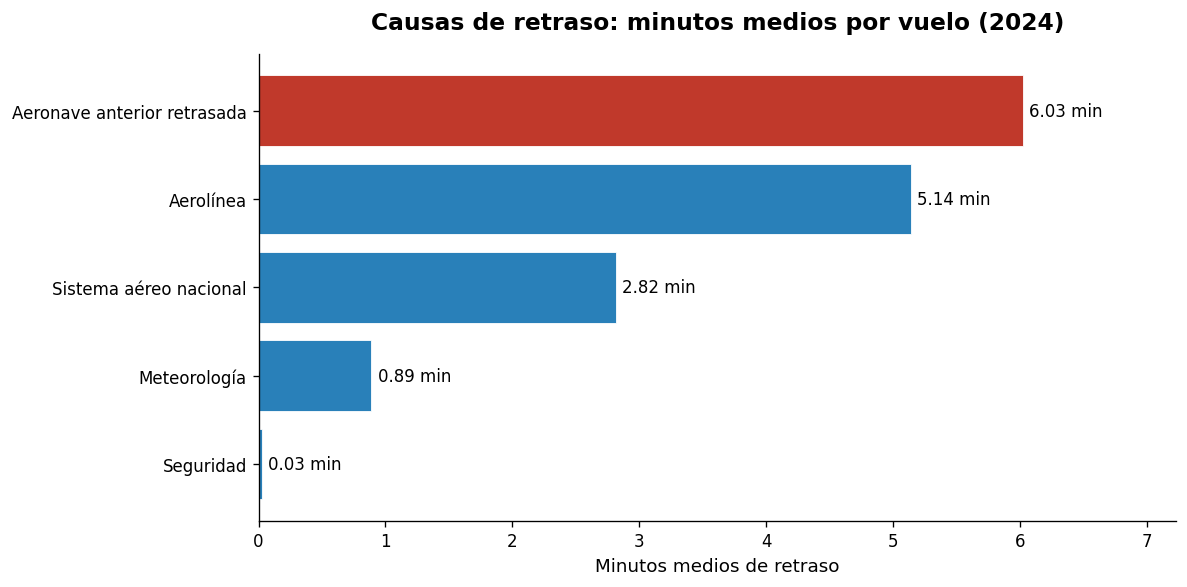

Grafica guardada correctamente.


In [8]:
causas = {
    'Aerolínea': df['carrier_delay'].mean(),
    'Meteorología': df['weather_delay'].mean(),
    'Sistema aéreo nacional': df['nas_delay'].mean(),
    'Seguridad': df['security_delay'].mean(),
    'Aeronave anterior retrasada': df['late_aircraft_delay'].mean()
}

causas_df = pd.DataFrame(list(causas.items()), columns=['Causa', 'Minutos medios'])
causas_df = causas_df.sort_values('Minutos medios', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(causas_df['Causa'], causas_df['Minutos medios'],
               color=['#c0392b' if v == causas_df['Minutos medios'].max()
                      else '#2980b9' for v in causas_df['Minutos medios']],
               edgecolor='white', linewidth=0.5)

ax.set_title('Causas de retraso: minutos medios por vuelo (2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Minutos medios de retraso', fontsize=11)

for bar, val in zip(bars, causas_df['Minutos medios']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} min', va='center', fontsize=10)

ax.set_xlim(0, causas_df['Minutos medios'].max() * 1.2)
plt.tight_layout()
plt.savefig('causas_retraso.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

### 3.4 Retrasos por día de la semana

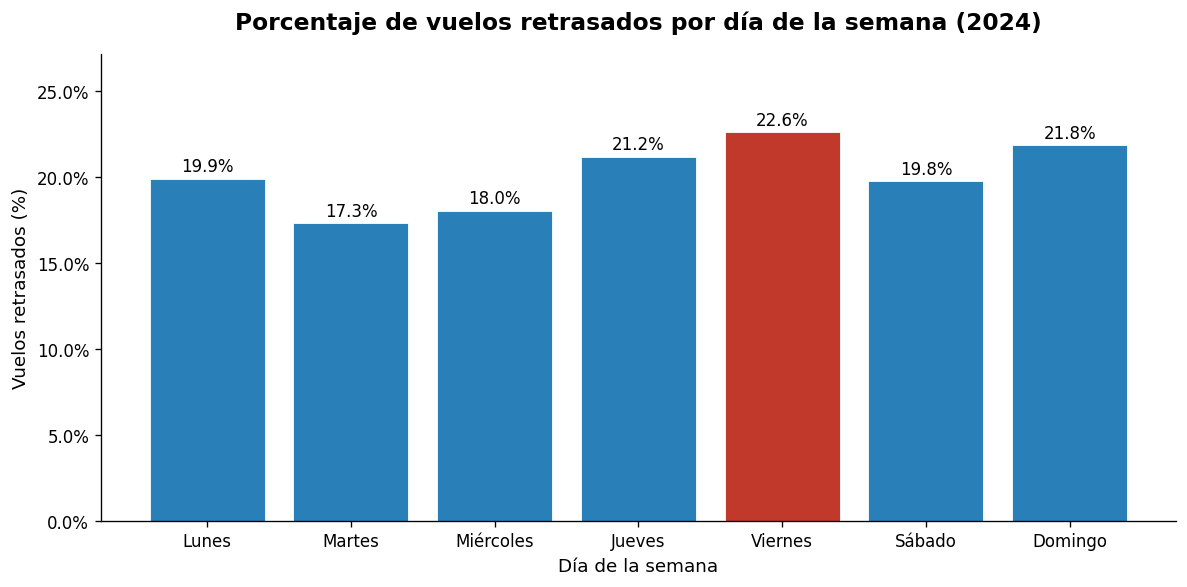

Grafica guardada correctamente.


In [9]:
nombres_dias = {1:'Lunes', 2:'Martes', 3:'Miércoles',
                4:'Jueves', 5:'Viernes', 6:'Sábado', 7:'Domingo'}

retrasos_dia = df.groupby('day_of_week')['retraso'].mean() * 100
retrasos_dia.index = retrasos_dia.index.map(nombres_dias)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(retrasos_dia.index, retrasos_dia.values,
              color=['#c0392b' if v == retrasos_dia.max()
                     else '#2980b9' for v in retrasos_dia.values],
              edgecolor='white', linewidth=0.5)

ax.set_title('Porcentaje de vuelos retrasados por día de la semana (2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Día de la semana', fontsize=11)
ax.set_ylabel('Vuelos retrasados (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_ylim(0, retrasos_dia.max() * 1.2)

for bar, val in zip(bars, retrasos_dia.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('retrasos_por_dia.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

### 3.5 Top 10 rutas con mayor porcentaje de retraso

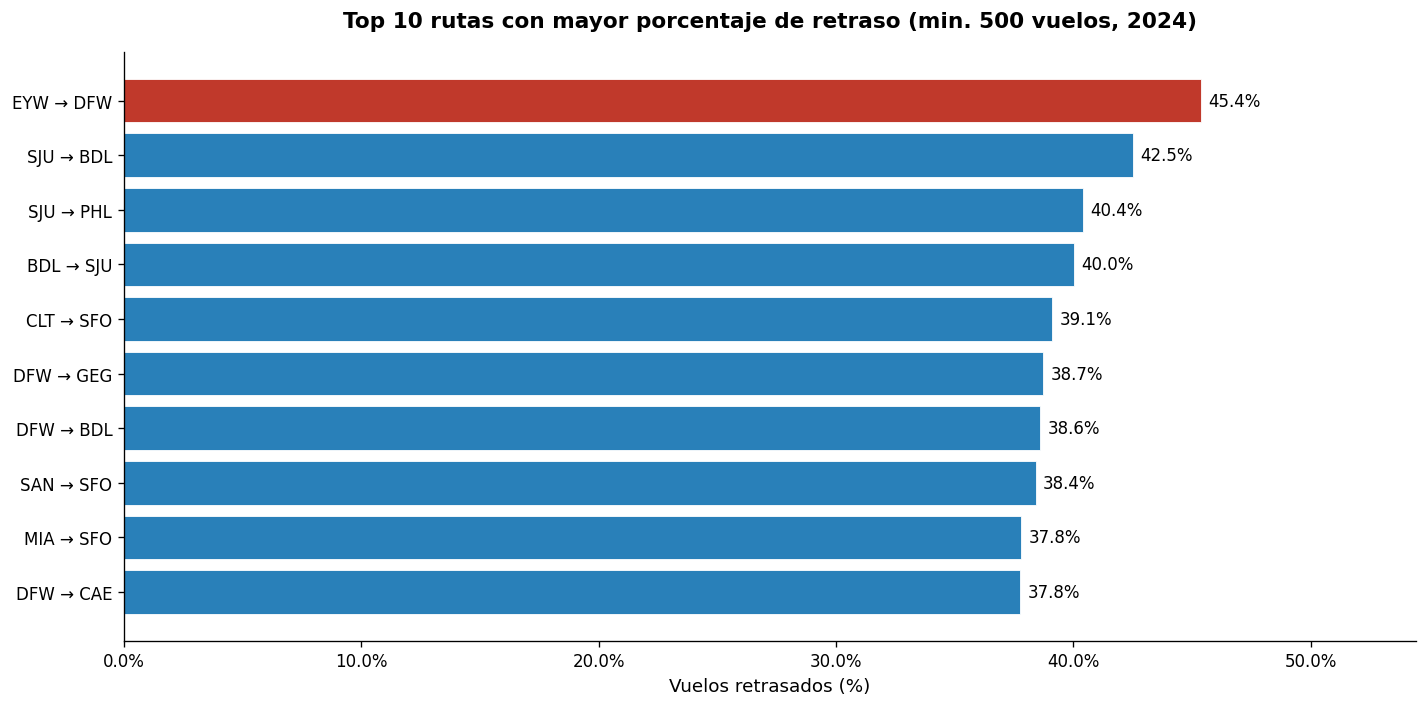

Grafica guardada correctamente.


In [10]:
df['ruta'] = df['origin'] + ' → ' + df['dest']

retrasos_ruta = df.groupby('ruta').agg(
    pct_retraso=('retraso', 'mean'),
    total_vuelos=('retraso', 'count')
).reset_index()

retrasos_ruta['pct_retraso'] = retrasos_ruta['pct_retraso'] * 100

# Solo rutas con suficiente volumen para ser representativas
retrasos_ruta = retrasos_ruta[retrasos_ruta['total_vuelos'] >= 500]
top10_rutas = retrasos_ruta.sort_values('pct_retraso', ascending=False).head(10)
top10_rutas = top10_rutas.sort_values('pct_retraso', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_rutas['ruta'], top10_rutas['pct_retraso'],
               color=['#c0392b' if v == top10_rutas['pct_retraso'].max()
                      else '#2980b9' for v in top10_rutas['pct_retraso']],
               edgecolor='white', linewidth=0.5)

ax.set_title('Top 10 rutas con mayor porcentaje de retraso (min. 500 vuelos, 2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Vuelos retrasados (%)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

for bar, val in zip(bars, top10_rutas['pct_retraso']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, top10_rutas['pct_retraso'].max() * 1.2)
plt.tight_layout()
plt.savefig('top10_rutas.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

## 4. Preprocesamiento y transformación de variables

In [11]:
# Selección de variables predictoras disponibles ANTES del vuelo
# (no usamos variables que solo se conocen una vez el vuelo ha ocurrido)
features = [
    'month', 'day_of_month', 'day_of_week',
    'op_unique_carrier', 'origin', 'dest',
    'crs_dep_time', 'crs_arr_time',
    'crs_elapsed_time', 'distance'
]

target = 'retraso'

# Eliminamos nulos en las columnas seleccionadas
df_model = df[features + [target]].dropna().copy()

# Convertimos hora de salida y llegada en franjas horarias (más útil para el modelo)
df_model['franja_salida'] = (df_model['crs_dep_time'] // 100).astype(int)
df_model['franja_llegada'] = (df_model['crs_arr_time'] // 100).astype(int)
df_model = df_model.drop(columns=['crs_dep_time', 'crs_arr_time'])

# Codificación de variables categóricas
from sklearn.preprocessing import LabelEncoder

for col in ['op_unique_carrier', 'origin', 'dest']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f"Dataset listo para modelizar: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas")
print(f"\nVariables predictoras: {[c for c in df_model.columns if c != target]}")
print(f"\nDistribución de la variable objetivo:")
print(df_model[target].value_counts(normalize=True).round(3) * 100)

Dataset listo para modelizar: 6,965,267 filas x 11 columnas

Variables predictoras: ['month', 'day_of_month', 'day_of_week', 'op_unique_carrier', 'origin', 'dest', 'crs_elapsed_time', 'distance', 'franja_salida', 'franja_llegada']

Distribución de la variable objetivo:
retraso
0    79.9
1    20.1
Name: proportion, dtype: float64


## 5. Modelización
### 5.1 División del dataset en entrenamiento y test

In [12]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[target])
y = df_model[target]

# Usamos una muestra de 1 millón de filas para que los modelos
# entrenen en un tiempo razonable en Colab
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=1_000_000, random_state=42, stratify=y
)

# División 80% entrenamiento / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]:,} filas")
print(f"Conjunto de test:          {X_test.shape[0]:,} filas")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Conjunto de entrenamiento: 800,000 filas
Conjunto de test:          200,000 filas

Distribución en entrenamiento:
retraso
0    79.9
1    20.1
Name: proportion, dtype: float64


### 5.2 Modelo 1: Regresión Logística (baseline)

Entrenando Regresión Logística...
Tiempo de entrenamiento: 52.9 segundos

AUC-ROC: 0.6252

Reporte de clasificación:
              precision    recall  f1-score   support

     Puntual       0.80      1.00      0.89    159703
   Retrasado       0.00      0.00      0.00     40297

    accuracy                           0.80    200000
   macro avg       0.40      0.50      0.44    200000
weighted avg       0.64      0.80      0.71    200000



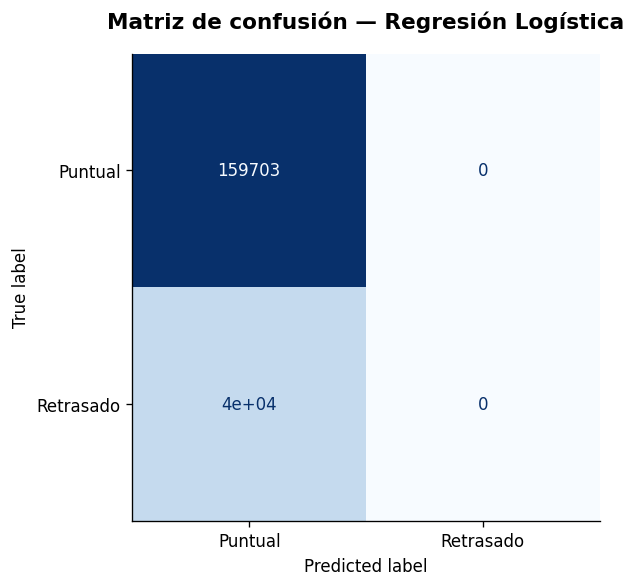

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import time

print("Entrenando Regresión Logística...")
inicio = time.time()

modelo_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
modelo_lr.fit(X_train, y_train)

tiempo_lr = time.time() - inicio
print(f"Tiempo de entrenamiento: {tiempo_lr:.1f} segundos")

# Predicciones
y_pred_lr = modelo_lr.predict(X_test)
y_prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

# Métricas
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"\nAUC-ROC: {auc_lr:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Puntual', 'Retrasado']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Puntual', 'Retrasado'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Regresión Logística',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_lr.png', bbox_inches='tight')
plt.show()

### 5.3 Modelo 2: Random Forest

Entrenando Random Forest...
Tiempo de entrenamiento: 147.7 segundos

AUC-ROC: 0.6994

Reporte de clasificación:
              precision    recall  f1-score   support

     Puntual       0.87      0.73      0.79    159703
   Retrasado       0.34      0.55      0.42     40297

    accuracy                           0.70    200000
   macro avg       0.60      0.64      0.61    200000
weighted avg       0.76      0.70      0.72    200000



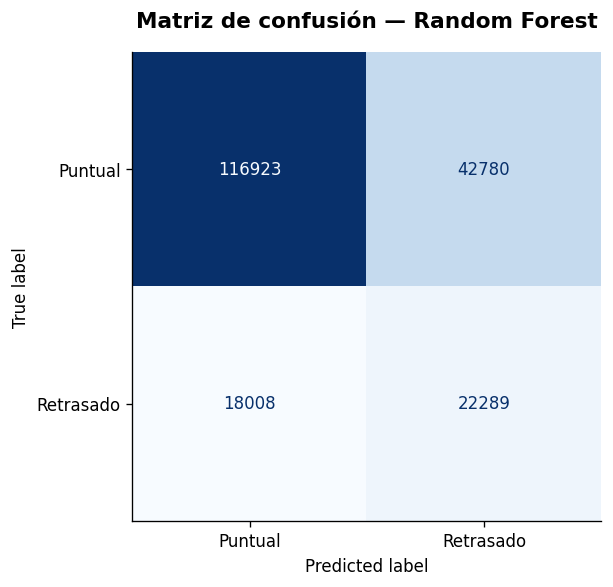

In [14]:
from sklearn.ensemble import RandomForestClassifier

print("Entrenando Random Forest...")
inicio = time.time()

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

tiempo_rf = time.time() - inicio
print(f"Tiempo de entrenamiento: {tiempo_rf:.1f} segundos")

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\nAUC-ROC: {auc_rf:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Puntual', 'Retrasado']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Puntual', 'Retrasado'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Random Forest',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_rf.png', bbox_inches='tight')
plt.show()

### 5.4 Modelo 3: XGBoost

Entrenando XGBoost...
Tiempo de entrenamiento: 16.6 segundos

AUC-ROC: 0.7156

Reporte de clasificación:
              precision    recall  f1-score   support

     Puntual       0.88      0.67      0.76    159703
   Retrasado       0.33      0.64      0.44     40297

    accuracy                           0.67    200000
   macro avg       0.61      0.66      0.60    200000
weighted avg       0.77      0.67      0.70    200000



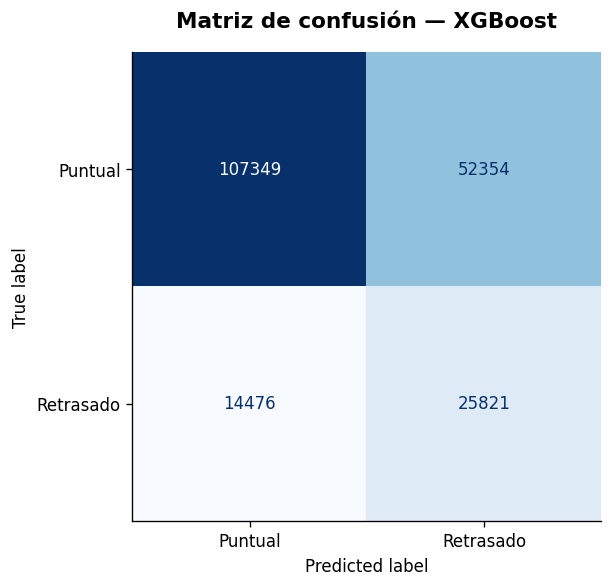

In [15]:
from xgboost import XGBClassifier

print("Entrenando XGBoost...")
inicio = time.time()

# Calculamos el peso para compensar el desbalance
escala = (y_train == 0).sum() / (y_train == 1).sum()

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=escala,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)
modelo_xgb.fit(X_train, y_train)

tiempo_xgb = time.time() - inicio
print(f"Tiempo de entrenamiento: {tiempo_xgb:.1f} segundos")

# Predicciones
y_pred_xgb = modelo_xgb.predict(X_test)
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"\nAUC-ROC: {auc_xgb:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Puntual', 'Retrasado']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Puntual', 'Retrasado'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — XGBoost',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_xgb.png', bbox_inches='tight')
plt.show()

## 6. Comparativa de modelos

Tabla comparativa de modelos:
             Modelo  AUC-ROC  Tiempo entrenamiento (s)  Retrasados detectados  % Retrasados detectados
Regresión Logística 0.625167                 52.908396                      0                      0.0
      Random Forest 0.699379                147.721847                  22289                     55.3
            XGBoost 0.715583                 16.566271                  25821                     64.1


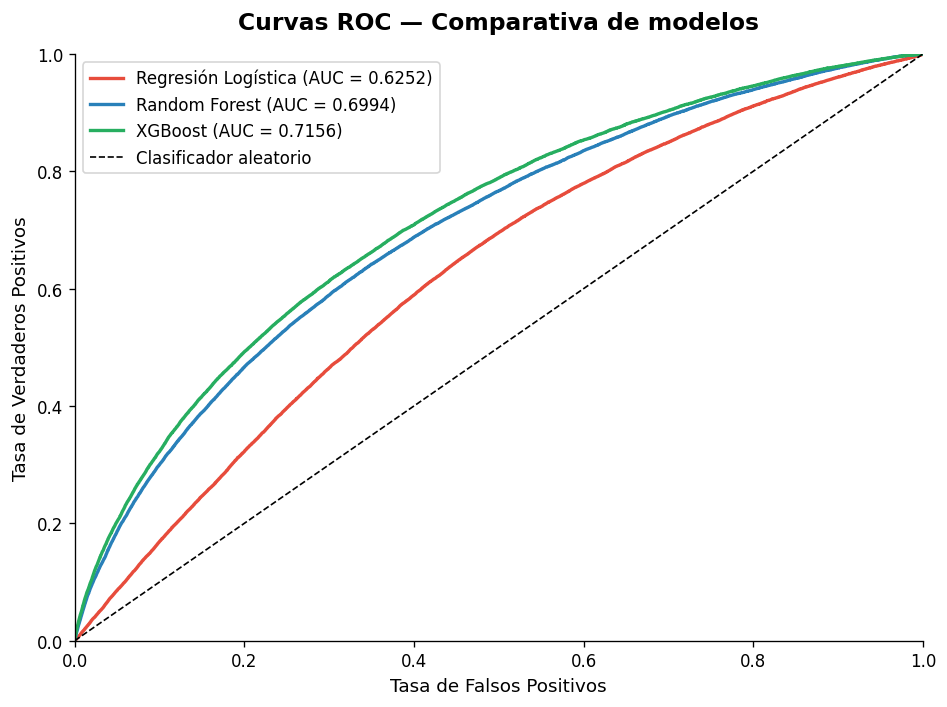

Grafica guardada correctamente.


In [16]:
from sklearn.metrics import roc_curve

# Tabla comparativa
comparativa = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_rf, auc_xgb],
    'Tiempo entrenamiento (s)': [tiempo_lr, tiempo_rf, tiempo_xgb],
    'Retrasados detectados': [
        int(confusion_matrix(y_test, y_pred_lr)[1,1]),
        int(confusion_matrix(y_test, y_pred_rf)[1,1]),
        int(confusion_matrix(y_test, y_pred_xgb)[1,1])
    ],
    'Total retrasados reales': [40297, 40297, 40297]
})
comparativa['% Retrasados detectados'] = (
    comparativa['Retrasados detectados'] /
    comparativa['Total retrasados reales'] * 100
).round(1)

print("Tabla comparativa de modelos:")
print(comparativa[['Modelo','AUC-ROC','Tiempo entrenamiento (s)',
                    'Retrasados detectados','% Retrasados detectados']].to_string(index=False))

# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, y_prob, color in [
    ('Regresión Logística', y_prob_lr, '#e74c3c'),
    ('Random Forest',       y_prob_rf, '#2980b9'),
    ('XGBoost',             y_prob_xgb,'#27ae60')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})', linewidth=2, color=color)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.set_title('Curvas ROC — Comparativa de modelos',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('curvas_roc.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

## 7. Interpretabilidad del modelo — SHAP values

Calculando SHAP values (puede tardar unos minutos)...


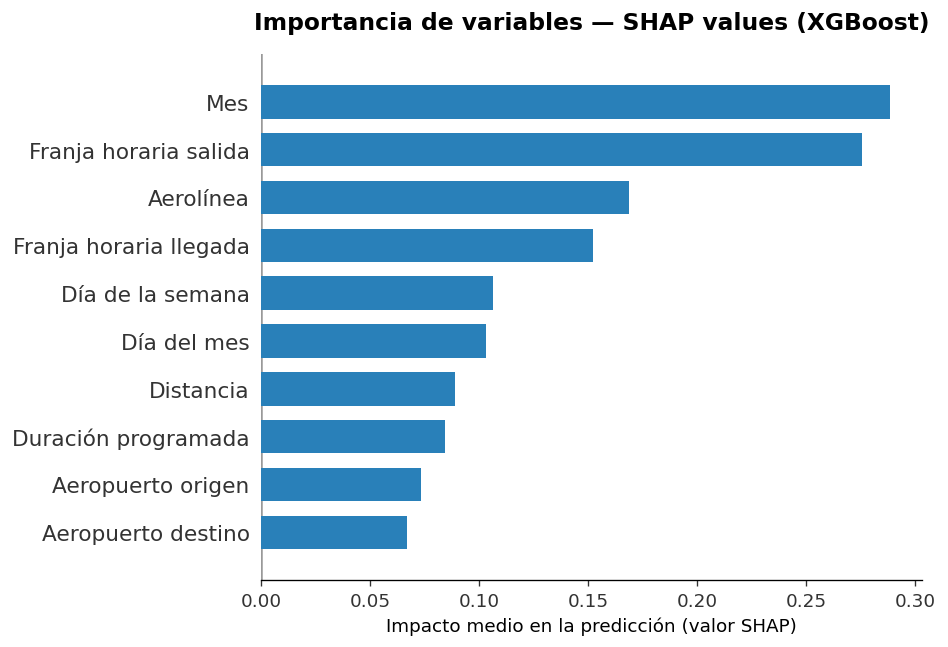

Grafica guardada correctamente.


In [17]:
!pip install shap -q

import shap

print("Calculando SHAP values (puede tardar unos minutos)...")

# Usamos una muestra de 5000 filas para que sea manejable
X_shap = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_shap)

# Nombres legibles para las variables
nombres_variables = {
    'month': 'Mes',
    'day_of_month': 'Día del mes',
    'day_of_week': 'Día de la semana',
    'op_unique_carrier': 'Aerolínea',
    'origin': 'Aeropuerto origen',
    'dest': 'Aeropuerto destino',
    'crs_elapsed_time': 'Duración programada',
    'distance': 'Distancia',
    'franja_salida': 'Franja horaria salida',
    'franja_llegada': 'Franja horaria llegada'
}

X_shap_renamed = X_shap.rename(columns=nombres_variables)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_renamed,
                  plot_type='bar', show=False,
                  color='#2980b9')
plt.title('Importancia de variables — SHAP values (XGBoost)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Impacto medio en la predicción (valor SHAP)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_importancia.png', bbox_inches='tight')
plt.show()
print("Grafica guardada correctamente.")

## 8. Prototipo productivizable — Predictor de retrasos

In [18]:
import pickle
import numpy as np

# Guardamos el modelo entrenado
pickle.dump(modelo_xgb, open('modelo_retrasos.pkl', 'wb'))
print("Modelo guardado correctamente.")

# Diccionarios de codificación para que el usuario pueda
# introducir valores legibles
aerolineas_codigo = {
    'American Airlines': 'AA', 'Delta Air Lines': 'DL',
    'United Airlines': 'UA', 'Southwest Airlines': 'WN',
    'JetBlue': 'B6', 'Alaska Airlines': 'AS',
    'Spirit Airlines': 'NK', 'Frontier Airlines': 'F9',
    'Allegiant Air': 'G4', 'Hawaiian Airlines': 'HA',
    'SkyWest Airlines': 'OO', 'Republic Airways': 'YX'
}

# Recuperamos los encoders originales para transformar los inputs
from sklearn.preprocessing import LabelEncoder

le_carrier = LabelEncoder()
le_carrier.fit(df['op_unique_carrier'].astype(str))

le_origin = LabelEncoder()
le_origin.fit(df['origin'].astype(str))

le_dest = LabelEncoder()
le_dest.fit(df['dest'].astype(str))

def predecir_retraso(aerolinea, origen, destino,
                     mes, dia_semana, hora_salida):
    """
    Predice la probabilidad de retraso de un vuelo.

    Parámetros:
    - aerolinea  : código IATA (ej. 'AA', 'DL', 'WN')
    - origen     : código IATA del aeropuerto origen (ej. 'JFK', 'LAX')
    - destino    : código IATA del aeropuerto destino (ej. 'ORD', 'DFW')
    - mes        : número del mes (1-12)
    - dia_semana : día de la semana (1=Lunes, 7=Domingo)
    - hora_salida: hora programada de salida en formato HHMM (ej. 800, 1430)

    Retorna:
    - Probabilidad de retraso superior a 15 minutos
    - Clasificación: 'PROBABLE RETRASO' o 'VUELO PUNTUAL'
    """
    try:
        carrier_enc = le_carrier.transform([aerolinea])[0]
    except:
        carrier_enc = 0
    try:
        origin_enc = le_origin.transform([origen])[0]
    except:
        origin_enc = 0
    try:
        dest_enc = le_dest.transform([destino])[0]
    except:
        dest_enc = 0

    franja_salida = hora_salida // 100
    franja_llegada = (hora_salida + 200) // 100  # estimación simple

    # Estimaciones típicas según distancia media
    distancia_media = df[
        (df['origin'] == origen) & (df['dest'] == destino)
    ]['distance'].mean()
    if np.isnan(distancia_media):
        distancia_media = 833  # media general del dataset

    duracion_media = df[
        (df['origin'] == origen) & (df['dest'] == destino)
    ]['crs_elapsed_time'].mean()
    if np.isnan(duracion_media):
        duracion_media = 150

    X_input = pd.DataFrame([{
        'month': mes,
        'day_of_month': 15,
        'day_of_week': dia_semana,
        'op_unique_carrier': carrier_enc,
        'origin': origin_enc,
        'dest': dest_enc,
        'crs_elapsed_time': duracion_media,
        'distance': distancia_media,
        'franja_salida': franja_salida,
        'franja_llegada': franja_llegada
    }])

    probabilidad = modelo_xgb.predict_proba(X_input)[0][1]
    clasificacion = 'PROBABLE RETRASO' if probabilidad > 0.5 else 'VUELO PUNTUAL'

    print(f"--- Resultado de la prediccion ---")
    print(f"Ruta:              {origen} -> {destino}")
    print(f"Aerolinea:         {aerolinea}")
    print(f"Mes:               {mes} | Dia semana: {dia_semana} | Hora: {hora_salida}")
    print(f"Distancia:         {distancia_media:.0f} millas")
    print(f"Duracion estimada: {duracion_media:.0f} minutos")
    print(f"Probabilidad de retraso: {probabilidad*100:.1f}%")
    print(f"Clasificacion:     {clasificacion}")
    print(f"---------------------------------")

    return probabilidad, clasificacion

# Ejemplos de uso
print("EJEMPLO 1: Frontier Airlines, vuelo de verano en hora punta")
predecir_retraso('F9', 'LAX', 'DFW', mes=7, dia_semana=5, hora_salida=1700)

print("\nEJEMPLO 2: Delta Air Lines, martes de octubre por la manana")
predecir_retraso('DL', 'JFK', 'LAX', mes=10, dia_semana=2, hora_salida=800)

Modelo guardado correctamente.
EJEMPLO 1: Frontier Airlines, vuelo de verano en hora punta
--- Resultado de la prediccion ---
Ruta:              LAX -> DFW
Aerolinea:         F9
Mes:               7 | Dia semana: 5 | Hora: 1700
Distancia:         1235 millas
Duracion estimada: 186 minutos
Probabilidad de retraso: 83.5%
Clasificacion:     PROBABLE RETRASO
---------------------------------

EJEMPLO 2: Delta Air Lines, martes de octubre por la manana
--- Resultado de la prediccion ---
Ruta:              JFK -> LAX
Aerolinea:         DL
Mes:               10 | Dia semana: 2 | Hora: 800
Distancia:         2475 millas
Duracion estimada: 375 minutos
Probabilidad de retraso: 17.7%
Clasificacion:     VUELO PUNTUAL
---------------------------------


(np.float32(0.17664249), 'VUELO PUNTUAL')

## 9. Conclusiones

In [20]:
conclusiones = ("CONCLUSIONES DEL PROYECTO\n"
    "==========================\n\n"
    "1. DATASET\n"
    "   - 7.079.081 vuelos domesticos en EE.UU. durante 2024.\n"
    "   - Tras filtrar cancelaciones y valores nulos: 6.965.267 vuelos validos.\n"
    "   - El 20.1% de los vuelos sufrieron un retraso superior a 15 minutos.\n\n"
    "2. HALLAZGOS DEL ANALISIS EXPLORATORIO\n"
    "   - Julio es el mes con mayor tasa de retrasos (28.9%).\n"
    "   - Octubre y Noviembre son los meses mas puntuales (12.7% y 14.1%).\n"
    "   - Frontier Airlines lidera los retrasos con un 28.0%.\n"
    "   - Republic Airways es la mas puntual con un 13.6%.\n"
    "   - El viernes es el dia con mas retrasos (22.6%).\n"
    "   - La causa principal de retraso es la aeronave anterior retrasada\n"
    "     (6.03 min de media), no la meteorologia como se podria intuir.\n\n"
    "3. MODELIZACION\n"
    "   - Regresion Logistica: AUC 0.6252. No detecta vuelos retrasados.\n"
    "   - Random Forest: AUC 0.6994. Detecta el 55.3% de los retrasos.\n"
    "   - XGBoost: AUC 0.7156. Detecta el 64.1% de los retrasos en 19 segundos.\n"
    "   - Modelo seleccionado como definitivo: XGBoost.\n\n"
    "4. INTERPRETABILIDAD (SHAP)\n"
    "   - Variables mas influyentes: mes, franja horaria de salida y aerolinea.\n"
    "   - Aeropuerto de origen y destino tienen el menor impacto relativo.\n\n"
    "5. PROTOTIPO PRODUCTIVIZABLE\n"
    "   - Funcion en Python que devuelve probabilidad de retraso dado un vuelo.\n"
    "   - Frontier Airlines, julio, viernes 17:00h -> 83.5% probabilidad.\n"
    "   - Delta Air Lines, octubre, martes 08:00h -> 17.7% probabilidad.\n\n"
    "6. LINEAS FUTURAS\n"
    "   - Incorporar datos meteorologicos en tiempo real por aeropuerto.\n"
    "   - Ampliar el modelo con datos historicos de anos anteriores.\n"
    "   - Desarrollar una aplicacion web interactiva con Streamlit.\n"
    "   - Implementar modelos de series temporales para predecir congestion.\n"
)

print(conclusiones)

CONCLUSIONES DEL PROYECTO

1. DATASET
   - 7.079.081 vuelos domesticos en EE.UU. durante 2024.
   - Tras filtrar cancelaciones y valores nulos: 6.965.267 vuelos validos.
   - El 20.1% de los vuelos sufrieron un retraso superior a 15 minutos.

2. HALLAZGOS DEL ANALISIS EXPLORATORIO
   - Julio es el mes con mayor tasa de retrasos (28.9%).
   - Octubre y Noviembre son los meses mas puntuales (12.7% y 14.1%).
   - Frontier Airlines lidera los retrasos con un 28.0%.
   - Republic Airways es la mas puntual con un 13.6%.
   - El viernes es el dia con mas retrasos (22.6%).
   - La causa principal de retraso es la aeronave anterior retrasada
     (6.03 min de media), no la meteorologia como se podria intuir.

3. MODELIZACION
   - Regresion Logistica: AUC 0.6252. No detecta vuelos retrasados.
   - Random Forest: AUC 0.6994. Detecta el 55.3% de los retrasos.
   - XGBoost: AUC 0.7156. Detecta el 64.1% de los retrasos en 19 segundos.
   - Modelo seleccionado como definitivo: XGBoost.

4. INTERPRETA